In [29]:
import os
import pandas as pd
import pymongo
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
# Verbindung zur Datenbank herstellen und Daten laden
def load_data():
    # Verbindung zur Datenbank herstellen
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()

    # Daten aus der 'canvassamples'-Collection laden
    canvassamples_collection = db['canvassamples']
    canvassamples_cursor = canvassamples_collection.find()
    canvassamples_data = list(canvassamples_cursor)
    canvassamples_df = pd.DataFrame(canvassamples_data)

    return canvassamples_df

# Daten laden
canvassamples_df = load_data()

In [31]:
# Anzeigen der ersten 5 Zeilen des DataFrames canvassamples_df
print("Erste 5 Zeilen des DataFrames canvassamples_df:")
display(canvassamples_df.head())

Erste 5 Zeilen des DataFrames canvassamples_df:


,_id,fingerprintId,sampleData,createdAt,__v
0,66e326e9fab6918841db55df,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:45.906,0
1,66e326e9fab6918841db55db,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:45.847,0
2,66e326e9fab6918841db55d6,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:45.772,0
3,66e326e9fab6918841db55e3,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:45.981,0
4,66e326eafab6918841db55eb,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:46.118,0


Canvas-Fingerprint 1:


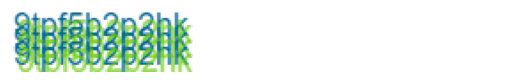

Canvas-Fingerprint 2:


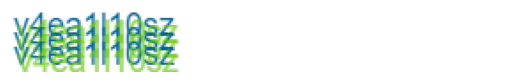

Canvas-Fingerprint 3:


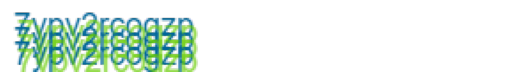

Canvas-Fingerprint 4:


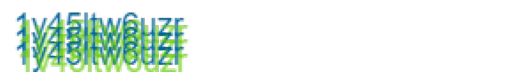

Canvas-Fingerprint 5:


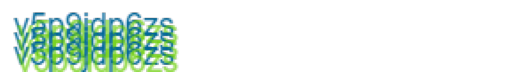

In [32]:
import base64
from PIL import Image
from io import BytesIO

# Funktion zum Dekodieren und Anzeigen eines Base64-codierten Bildes
def display_base64_image(base64_string):
    image_data = base64.b64decode(base64_string)
    image = Image.open(BytesIO(image_data))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

# Beispielhafte Anzeige der ersten 5 Canvas-Fingerprints
for i in range(5):
    print(f"Canvas-Fingerprint {i+1}:")
    display_base64_image(canvassamples_df['sampleData'].iloc[i])

In [33]:
# Länge der Base64-codierten Strings analysieren
canvassamples_df['sampleData_length'] = canvassamples_df['sampleData'].apply(len)

# Statistische Analyse der Länge der Base64-codierten Strings
print("Statistische Analyse der Länge der Base64-codierten Strings (sampleData):")
display(canvassamples_df['sampleData_length'].describe())

Statistische Analyse der Länge der Base64-codierten Strings (sampleData):


count    2.004832e+06
mean     8.562155e+03
std      9.619824e+02
min      3.968000e+03
25%      7.916000e+03
50%      8.576000e+03
75%      9.220000e+03
max      1.282800e+04
Name: sampleData_length, dtype: float64

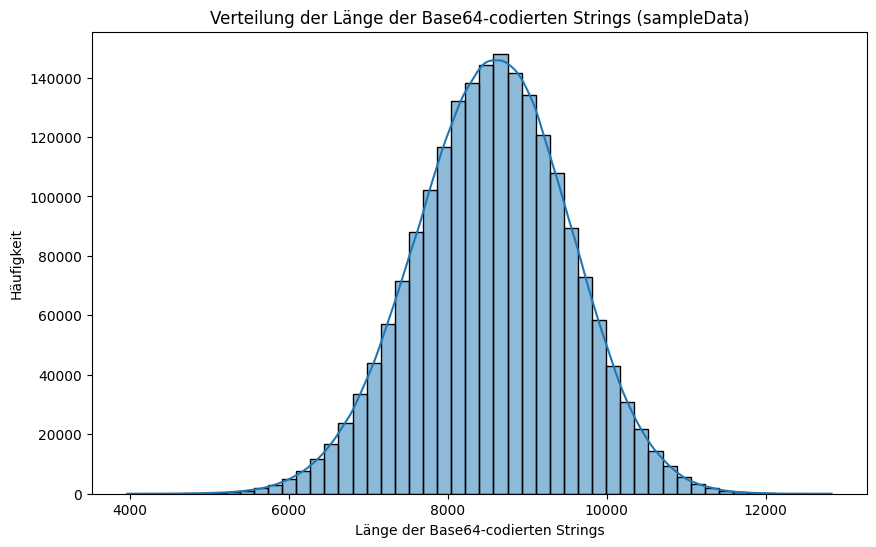

In [34]:
# Histogramm der Länge der Base64-codierten Strings
plt.figure(figsize=(10, 6))
sns.histplot(canvassamples_df['sampleData_length'], bins=50, kde=True)
plt.title('Verteilung der Länge der Base64-codierten Strings (sampleData)')
plt.xlabel('Länge der Base64-codierten Strings')
plt.ylabel('Häufigkeit')
plt.show()

Zusammenfassung der statistischen Analyse der Länge der Base64-codierten Strings (sampleData):
count    2.004832e+06
mean     8.562155e+03
std      9.619824e+02
min      3.968000e+03
25%      7.916000e+03
50%      8.576000e+03
75%      9.220000e+03
max      1.282800e+04
Name: sampleData_length, dtype: float64
Canvas-Fingerprint 1:


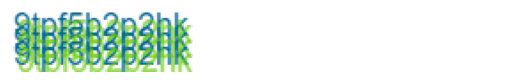

Canvas-Fingerprint 2:


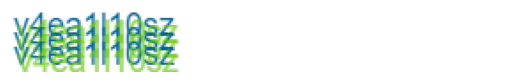

Canvas-Fingerprint 3:


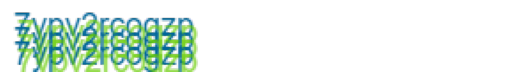

Canvas-Fingerprint 4:


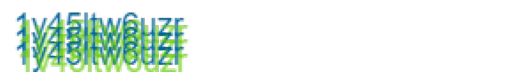

Canvas-Fingerprint 5:


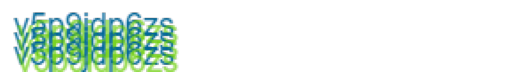

In [35]:
# Zusammenfassung der Ergebnisse
summary = canvassamples_df['sampleData_length'].describe()
print("Zusammenfassung der statistischen Analyse der Länge der Base64-codierten Strings (sampleData):")
print(summary)

# Visualisierung der ersten 5 Canvas-Fingerprints
for i in range(5):
    print(f"Canvas-Fingerprint {i+1}:")
    display_base64_image(canvassamples_df['sampleData'].iloc[i])

Statistische Analyse der Länge der Base64-codierten Strings für Benutzer 1:


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: sampleData_length, dtype: float64

Statistische Analyse der Länge der Base64-codierten Strings für Benutzer 2:


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: sampleData_length, dtype: float64

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


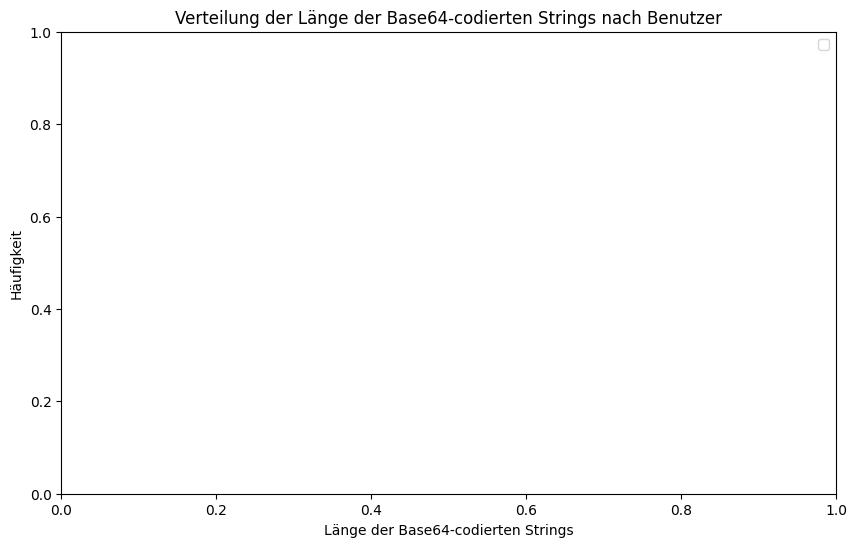

In [36]:
# Beispielhafte Benutzer-IDs
benutzer_1_id = '66e326e8fab6918841db55d1'
benutzer_2_id = '66e326e8fab6918841db55d2'

# Filtern der Daten nach Benutzer
benutzer_1_data = canvassamples_df[canvassamples_df['fingerprintId'] == benutzer_1_id]
benutzer_2_data = canvassamples_df[canvassamples_df['fingerprintId'] == benutzer_2_id]

# Statistische Analyse der Länge der Base64-codierten Strings nach Benutzer
print("Statistische Analyse der Länge der Base64-codierten Strings für Benutzer 1:")
display(benutzer_1_data['sampleData_length'].describe())

print("Statistische Analyse der Länge der Base64-codierten Strings für Benutzer 2:")
display(benutzer_2_data['sampleData_length'].describe())

# Grafische Darstellung der Länge der Base64-codierten Strings nach Benutzer
plt.figure(figsize=(10, 6))
sns.histplot(benutzer_1_data['sampleData_length'], bins=50, kde=True, color='blue', label='Benutzer 1')
sns.histplot(benutzer_2_data['sampleData_length'], bins=50, kde=True, color='red', label='Benutzer 2')
plt.title('Verteilung der Länge der Base64-codierten Strings nach Benutzer')
plt.xlabel('Länge der Base64-codierten Strings')
plt.ylabel('Häufigkeit')
plt.legend()
plt.show()